# **Customer Lifetime Value (CLV) Forecasting using Artificial Neural Networks (ANN)**

---

## **Project Objective**

The objective of this project is to develop a **Customer Lifetime Value (CLV) Forecasting System** using an **Artificial Neural Network (ANN)** to predict the total future revenue that a business can expect from individual customers.

Customer Lifetime Value is a critical metric in modern business strategy, enabling organizations to understand the long-term value of customers and optimize marketing, retention, and acquisition efforts accordingly.

The system is designed to:

- Predict **future revenue contribution of each customer**  
- Identify **high-value and low-value customer segments**  
- Support **data-driven marketing and retention strategies**  
- Capture **complex, non-linear relationships in transactional data**  

This project is highly applicable in:
- e-commerce and retail platforms  
- SaaS and subscription-based businesses  
- CRM and marketing analytics systems  
- customer segmentation and personalization engines  

---

## **Dataset Used**

This project utilizes transactional datasets containing customer purchase behavior and historical revenue data.

### **Dataset Sources**

- **Online Retail Dataset (UCI Machine Learning Repository)**
- Kaggle transactional datasets (if extended)

### **Dataset Characteristics**

The dataset includes:

- **Customer-level transactional data**, such as:
  - purchase history  
  - transaction frequency  
  - recency of purchases  

- **Financial attributes**:
  - transaction amounts  
  - total revenue per customer  

- Derived features:
  - Recency (R)  
  - Frequency (F)  
  - Monetary value (M)  

Key characteristics:
- time-based behavior patterns  
- variability in customer spending  
- long-tail distribution of high-value customers  

### **How Dataset is Used in the Project**

The dataset is processed through a structured pipeline:

- **Data preprocessing**
  - cleaning transactional records  
  - handling missing or inconsistent entries  

- **Feature engineering**
  - creation of RFM (Recency, Frequency, Monetary) features  
  - aggregation of transaction-level data to customer-level  

- **Normalization and scaling**
  - ensures compatibility with ANN models  

- **Train-validation-test split**
  - preserves temporal and behavioral consistency  

- **Model training**
  - ANN trained to predict future customer value  

The dataset enables the model to learn **customer behavior patterns over time**, which are essential for accurate CLV forecasting.

---

## **Project Summary**

This project presents a complete implementation of a **Customer Lifetime Value Forecasting System using Artificial Neural Networks**, focusing on predicting long-term customer revenue.

The workflow begins with transforming raw transactional data into meaningful customer-level features using RFM analysis. This step is critical in capturing behavioral patterns such as purchase frequency and spending habits.

The core of the system is an **Artificial Neural Network**, designed to model non-linear relationships between customer attributes and future value. The model learns patterns such as:
- high-frequency customers contributing more revenue  
- impact of recency on future engagement  
- relationship between past spending and future value  

The ANN architecture includes:
- input layer representing engineered features  
- hidden layers capturing complex interactions  
- output layer predicting **continuous CLV values**  

A key strength of this project is its ability to provide **continuous revenue predictions**, enabling businesses to rank customers based on expected future value rather than simple classification.

Evaluation is performed using:
- regression metrics such as MAE, MSE, and RMSE  
- distribution analysis of predicted vs actual values  

The system supports several business use cases, including:
- identifying high-value customers for targeted marketing  
- optimizing retention strategies  
- improving customer acquisition ROI  

Additionally, the project enables **customer segmentation based on predicted CLV**, allowing businesses to categorize customers into:
- high-value  
- medium-value  
- low-value segments  

Overall, this project demonstrates how deep learning can be applied to transactional data to build **revenue-driven, data-centric decision systems**.

---

## **Key Highlights**

- Built a **Customer Lifetime Value Forecasting system using ANN**, targeting revenue optimization.

- Focused on predicting **continuous customer value**, not just classification.

- Utilized transactional dataset:
  - Online Retail Dataset (UCI)  

- Performed advanced **feature engineering**, including:
  - RFM (Recency, Frequency, Monetary) analysis  
  - customer-level aggregation  

- Implemented a complete **data preprocessing pipeline**, including:
  - cleaning  
  - normalization  
  - scaling  

- Designed an **ANN architecture**, capable of:
  - capturing non-linear behavioral patterns  
  - modeling customer spending dynamics  

- Evaluated model performance using:
  - MAE, MSE, RMSE  
  - distribution comparisons  

- Enabled **customer segmentation based on predicted CLV**, supporting:
  - targeted marketing  
  - personalized engagement  

- Provided **business insights**, including:
  - identification of high-value customers  
  - optimization of retention strategies  

- Designed for **real-world deployment**, including:
  - CRM systems  
  - marketing analytics platforms  
  - revenue forecasting tools  

- Demonstrates strong expertise in:
  - **Artificial Neural Networks (ANN)**  
  - **customer analytics**  
  - **revenue forecasting models**

---


In [1]:

# ============================================
# Cell 1: Basic Imports
# ============================================

import os
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

In [2]:

# ============================================
# Cell 2: Visualization Imports
# ============================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from IPython.display import display

In [3]:

# ============================================
# Cell 3: Scikit-Learn Imports
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [4]:

# ============================================
# Cell 4: TensorFlow / Keras Imports
# ============================================

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Embedding,
    Flatten,
    Concatenate,
    BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model

In [5]:

# ============================================
# Cell 5: Global Configuration
# ============================================

SEED = 42
PROJECT_NAME = "customer_lifetime_value_forecasting_ann"
ARTIFACTS_DIR = Path("artifacts") / PROJECT_NAME

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("Artifacts directory:", ARTIFACTS_DIR.resolve())

Artifacts directory: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\ANN Classification\Customer Lifetime Value Forecasting\artifacts\customer_lifetime_value_forecasting_ann


In [6]:

# ============================================
# Cell 6: Reproducibility
# ============================================

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seeds set successfully.")

Seeds set successfully.


## 4. Business Design

We will create a realistic customer analytics pipeline with the following flow:

1. Generate synthetic transactions  
2. Build customer-level features  
3. Create cohort and RFM-like signals  
4. Generate target variables:
   - future 90-day revenue
   - retention flag  
5. Run K-means segmentation  
6. Train a deep ANN with embeddings  
7. Evaluate business and ML outcomes  
8. Inspect prediction errors  
9. Show sample predictions  
10. Add optional deployment demo

In [7]:

# ============================================
# Cell 7: Helper Function for Pretty Display
# ============================================

def show_shape(name, obj):
    print(f"{name} shape: {obj.shape}")

In [8]:

# ============================================
# Cell 8: Synthetic Data Generation Parameters
# ============================================

N_CUSTOMERS = 6000
MIN_ORDERS = 2
MAX_ORDERS = 25

COUNTRIES = [
    "United Kingdom",
    "Germany",
    "France",
    "Spain",
    "Netherlands",
    "Belgium",
    "Ireland"
]

CHANNELS = ["Web", "Mobile App", "Email Campaign", "Marketplace"]
CATEGORIES = ["Home", "Gift", "Electronics", "Beauty", "Office", "Fashion", "Kids"]
PAYMENT_TYPES = ["Card", "PayPal", "Wallet", "Bank Transfer"]

REFERENCE_DATE = pd.Timestamp("2025-01-01")
OBS_WINDOW_END = pd.Timestamp("2024-09-30")
FORECAST_WINDOW_END = pd.Timestamp("2024-12-29")

## 5. Synthetic Transaction Creation

The generated dataset intentionally mimics:
- varying purchase frequency,
- customer tenure,
- order values,
- country/channel effects,
- repeat behavior,
- customer quality heterogeneity.

This makes the ANN project more realistic than a toy example.

In [9]:

# ============================================
# Cell 9: Build Customer Master Table
# ============================================

customer_ids = [f"CUST_{i:05d}" for i in range(1, N_CUSTOMERS + 1)]

customer_master = pd.DataFrame({
    "customer_id": customer_ids,
    "country": np.random.choice(COUNTRIES, size=N_CUSTOMERS, p=[0.40, 0.12, 0.12, 0.10, 0.10, 0.08, 0.08]),
    "preferred_channel": np.random.choice(CHANNELS, size=N_CUSTOMERS, p=[0.45, 0.30, 0.15, 0.10]),
    "signup_month": np.random.randint(1, 13, size=N_CUSTOMERS),
    "loyalty_score": np.clip(np.random.normal(loc=60, scale=18, size=N_CUSTOMERS), 5, 100),
    "discount_sensitivity": np.clip(np.random.beta(2, 5, size=N_CUSTOMERS), 0.01, 0.99),
    "engagement_score": np.clip(np.random.normal(loc=55, scale=20, size=N_CUSTOMERS), 1, 100)
})

customer_master.head()

,customer_id,country,preferred_channel,signup_month,loyalty_score,discount_sensitivity,engagement_score
0,CUST_00001,United Kingdom,Mobile App,6,41.965761,0.461893,64.721479
1,CUST_00002,Ireland,Web,4,68.173652,0.231197,40.920096
2,CUST_00003,Spain,Email Campaign,7,44.630771,0.170510,38.412520
3,CUST_00004,France,Mobile App,3,45.139166,0.446852,44.890168
4,CUST_00005,United Kingdom,Web,5,78.696159,0.189632,65.049807


In [10]:

# ============================================
# Cell 10: Generate Transaction Rows
# ============================================

records = []

for row in customer_master.itertuples(index=False):
    n_orders = np.random.randint(MIN_ORDERS, MAX_ORDERS + 1)

    customer_effect = (
        0.018 * row.loyalty_score
        + 0.015 * row.engagement_score
        - 8.0 * row.discount_sensitivity
    )

    for order_idx in range(n_orders):
        category = np.random.choice(CATEGORIES)
        channel = np.random.choice(CHANNELS, p=[0.42, 0.31, 0.15, 0.12])
        payment_type = np.random.choice(PAYMENT_TYPES)

        days_before_reference = np.random.randint(1, 730)
        order_date = REFERENCE_DATE - pd.Timedelta(days=int(days_before_reference))

        qty = np.random.randint(1, 8)

        category_base_price = {
            "Home": 18,
            "Gift": 12,
            "Electronics": 45,
            "Beauty": 22,
            "Office": 16,
            "Fashion": 30,
            "Kids": 20
        }[category]

        unit_price = max(
            2.0,
            np.random.normal(
                loc=category_base_price + customer_effect,
                scale=6.0
            )
        )

        discount_rate = np.random.beta(2, 6) * row.discount_sensitivity
        gross_value = qty * unit_price
        net_value = gross_value * (1 - discount_rate)

        records.append({
            "customer_id": row.customer_id,
            "country": row.country,
            "preferred_channel": row.preferred_channel,
            "transaction_channel": channel,
            "payment_type": payment_type,
            "product_category": category,
            "order_date": order_date,
            "quantity": qty,
            "unit_price": round(unit_price, 2),
            "discount_rate": round(discount_rate, 4),
            "order_value": round(net_value, 2),
            "signup_month": row.signup_month,
            "loyalty_score": round(row.loyalty_score, 2),
            "discount_sensitivity": round(row.discount_sensitivity, 4),
            "engagement_score": round(row.engagement_score, 2)
        })

transactions = pd.DataFrame(records)
transactions.head()

,customer_id,country,preferred_channel,transaction_channel,payment_type,product_category,order_date,quantity,unit_price,discount_rate,order_value,signup_month,loyalty_score,discount_sensitivity,engagement_score
0,CUST_00001,United Kingdom,Mobile App,Web,Bank Transfer,Home,2023-07-03,1,24.21,0.0633,22.67,6,41.97,0.4619,64.72
1,CUST_00001,United Kingdom,Mobile App,Web,PayPal,Fashion,2023-09-17,3,29.04,0.0818,80.01,6,41.97,0.4619,64.72
2,CUST_00001,United Kingdom,Mobile App,Marketplace,Bank Transfer,Home,2023-09-03,2,23.38,0.1693,38.84,6,41.97,0.4619,64.72
3,CUST_00001,United Kingdom,Mobile App,Mobile App,Card,Home,2023-10-03,7,13.28,0.1304,80.84,6,41.97,0.4619,64.72
4,CUST_00001,United Kingdom,Mobile App,Web,Bank Transfer,Gift,2023-06-19,5,4.95,0.1758,20.39,6,41.97,0.4619,64.72


In [11]:

# ============================================
# Cell 11: Sort Transactions
# ============================================

transactions = transactions.sort_values(["customer_id", "order_date"]).reset_index(drop=True)
show_shape("transactions", transactions)
transactions.head()

transactions shape: (80934, 15)


,customer_id,country,preferred_channel,transaction_channel,payment_type,product_category,order_date,quantity,unit_price,discount_rate,order_value,signup_month,loyalty_score,discount_sensitivity,engagement_score
0,CUST_00001,United Kingdom,Mobile App,Web,PayPal,Beauty,2023-04-29,3,27.11,0.1703,67.49,6,41.97,0.4619,64.72
1,CUST_00001,United Kingdom,Mobile App,Web,Bank Transfer,Gift,2023-06-19,5,4.95,0.1758,20.39,6,41.97,0.4619,64.72
2,CUST_00001,United Kingdom,Mobile App,Web,Bank Transfer,Home,2023-07-03,1,24.21,0.0633,22.67,6,41.97,0.4619,64.72
3,CUST_00001,United Kingdom,Mobile App,Web,PayPal,Gift,2023-07-08,1,11.10,0.0284,10.79,6,41.97,0.4619,64.72
4,CUST_00001,United Kingdom,Mobile App,Web,PayPal,Gift,2023-07-16,5,6.49,0.1832,26.50,6,41.97,0.4619,64.72


In [12]:

# ============================================
# Cell 12: Quick Data Quality Check
# ============================================

print(transactions.isna().sum())
print()
print(transactions.dtypes)

customer_id             0
country                 0
preferred_channel       0
transaction_channel     0
payment_type            0
product_category        0
order_date              0
quantity                0
unit_price              0
discount_rate           0
order_value             0
signup_month            0
loyalty_score           0
discount_sensitivity    0
engagement_score        0
dtype: int64

customer_id                        str
country                            str
preferred_channel                  str
transaction_channel                str
payment_type                       str
product_category                   str
order_date              datetime64[us]
quantity                         int64
unit_price                     float64
discount_rate                  float64
order_value                    float64
signup_month                     int64
loyalty_score                  float64
discount_sensitivity           float64
engagement_score               float64
dtype: obje

In [13]:

# ============================================
# Cell 13: Basic Transaction Summary
# ============================================

summary_table = pd.DataFrame({
    "metric": [
        "n_rows",
        "n_customers",
        "min_order_date",
        "max_order_date",
        "avg_order_value",
        "median_order_value"
    ],
    "value": [
        len(transactions),
        transactions["customer_id"].nunique(),
        transactions["order_date"].min(),
        transactions["order_date"].max(),
        transactions["order_value"].mean(),
        transactions["order_value"].median()
    ]
})

summary_table

,metric,value
0,n_rows,80934
1,n_customers,6000
2,min_order_date,2023-01-03 00:00:00
3,max_order_date,2024-12-31 00:00:00
4,avg_order_value,85.25249
5,median_order_value,69.23


## 6. Train / Forecast Window Design

We simulate a real forecasting problem by splitting time into:

- **observation window:** used for feature engineering
- **forecast window:** used for target generation

This is important because true CLV forecasting should be **time-aware**.

In [14]:

# ============================================
# Cell 14: Split Transactions by Time Window
# ============================================

obs_txn = transactions[transactions["order_date"] <= OBS_WINDOW_END].copy()
future_txn = transactions[
    (transactions["order_date"] > OBS_WINDOW_END) &
    (transactions["order_date"] <= FORECAST_WINDOW_END)
].copy()

show_shape("Observation transactions", obs_txn)
show_shape("Future transactions", future_txn)

Observation transactions shape: (70699, 15)
Future transactions shape: (10006, 15)


In [15]:

# ============================================
# Cell 15: Customer Coverage Check
# ============================================

obs_customers = set(obs_txn["customer_id"].unique())
future_customers = set(future_txn["customer_id"].unique())

print("Customers in observation window :", len(obs_customers))
print("Customers in forecast window    :", len(future_customers))
print("Overlap                         :", len(obs_customers & future_customers))

Customers in observation window : 5990
Customers in forecast window    : 4508
Overlap                         : 4498


## 7. Customer-Level Feature Engineering

We now aggregate transaction history into customer-level variables:

- frequency,
- monetary value,
- recency,
- average basket size,
- category diversity,
- channel usage,
- discount behavior,
- spending volatility,
- cohort signals.

In [16]:

# ============================================
# Cell 16: Observation Window Feature Base
# ============================================

customer_features = obs_txn.groupby("customer_id").agg(
    n_orders=("order_value", "count"),
    total_revenue=("order_value", "sum"),
    avg_order_value=("order_value", "mean"),
    std_order_value=("order_value", "std"),
    total_quantity=("quantity", "sum"),
    avg_quantity=("quantity", "mean"),
    last_order_date=("order_date", "max"),
    first_order_date=("order_date", "min"),
    category_diversity=("product_category", "nunique"),
    payment_diversity=("payment_type", "nunique"),
    channel_diversity=("transaction_channel", "nunique"),
    avg_discount=("discount_rate", "mean")
).reset_index()

customer_features.head()

,customer_id,n_orders,total_revenue,avg_order_value,std_order_value,total_quantity,avg_quantity,last_order_date,first_order_date,category_diversity,payment_diversity,channel_diversity,avg_discount
0,CUST_00001,13,531.55,40.888462,34.267782,43,3.307692,2024-09-17,2023-04-29,5,3,4,0.136546
1,CUST_00002,5,213.01,42.602000,58.033073,10,2.000000,2024-05-18,2023-01-17,4,3,3,0.095160
2,CUST_00003,16,1266.84,79.177500,47.317004,61,3.812500,2024-09-07,2023-01-10,7,4,4,0.047981
3,CUST_00004,7,636.79,90.970000,65.480430,23,3.285714,2024-09-09,2023-02-17,6,4,2,0.095829
4,CUST_00005,9,659.58,73.286667,53.972245,34,3.777778,2024-09-21,2023-01-22,7,3,3,0.063689


In [17]:

# ============================================
# Cell 17: Fill Feature Gaps
# ============================================

customer_features["std_order_value"] = customer_features["std_order_value"].fillna(0.0)
customer_features["avg_discount"] = customer_features["avg_discount"].fillna(0.0)

customer_features.head()

,customer_id,n_orders,total_revenue,avg_order_value,std_order_value,total_quantity,avg_quantity,last_order_date,first_order_date,category_diversity,payment_diversity,channel_diversity,avg_discount
0,CUST_00001,13,531.55,40.888462,34.267782,43,3.307692,2024-09-17,2023-04-29,5,3,4,0.136546
1,CUST_00002,5,213.01,42.602000,58.033073,10,2.000000,2024-05-18,2023-01-17,4,3,3,0.095160
2,CUST_00003,16,1266.84,79.177500,47.317004,61,3.812500,2024-09-07,2023-01-10,7,4,4,0.047981
3,CUST_00004,7,636.79,90.970000,65.480430,23,3.285714,2024-09-09,2023-02-17,6,4,2,0.095829
4,CUST_00005,9,659.58,73.286667,53.972245,34,3.777778,2024-09-21,2023-01-22,7,3,3,0.063689


In [18]:

# ============================================
# Cell 18: Recency / Tenure Features
# ============================================

customer_features["recency_days"] = (OBS_WINDOW_END - customer_features["last_order_date"]).dt.days
customer_features["tenure_days"] = (OBS_WINDOW_END - customer_features["first_order_date"]).dt.days + 1
customer_features["orders_per_month"] = customer_features["n_orders"] / np.maximum(customer_features["tenure_days"] / 30.0, 1)
customer_features["revenue_per_month"] = customer_features["total_revenue"] / np.maximum(customer_features["tenure_days"] / 30.0, 1)

customer_features.head()

,customer_id,n_orders,total_revenue,avg_order_value,std_order_value,total_quantity,avg_quantity,last_order_date,first_order_date,category_diversity,payment_diversity,channel_diversity,avg_discount,recency_days,tenure_days,orders_per_month,revenue_per_month
0,CUST_00001,13,531.55,40.888462,34.267782,43,3.307692,2024-09-17,2023-04-29,5,3,4,0.136546,13,521,0.748560,30.607486
1,CUST_00002,5,213.01,42.602000,58.033073,10,2.000000,2024-05-18,2023-01-17,4,3,3,0.095160,135,623,0.240770,10.257303
2,CUST_00003,16,1266.84,79.177500,47.317004,61,3.812500,2024-09-07,2023-01-10,7,4,4,0.047981,23,630,0.761905,60.325714
3,CUST_00004,7,636.79,90.970000,65.480430,23,3.285714,2024-09-09,2023-02-17,6,4,2,0.095829,21,592,0.354730,32.269764
4,CUST_00005,9,659.58,73.286667,53.972245,34,3.777778,2024-09-21,2023-01-22,7,3,3,0.063689,9,618,0.436893,32.018447


In [19]:

# ============================================
# Cell 19: Join Static Customer Attributes
# ============================================

model_df = customer_features.merge(
    customer_master,
    on="customer_id",
    how="left"
)

model_df.head()

,customer_id,n_orders,total_revenue,avg_order_value,std_order_value,total_quantity,avg_quantity,last_order_date,first_order_date,category_diversity,...,recency_days,tenure_days,orders_per_month,revenue_per_month,country,preferred_channel,signup_month,loyalty_score,discount_sensitivity,engagement_score
0,CUST_00001,13,531.55,40.888462,34.267782,43,3.307692,2024-09-17,2023-04-29,5,...,13,521,0.748560,30.607486,United Kingdom,Mobile App,6,41.965761,0.461893,64.721479
1,CUST_00002,5,213.01,42.602000,58.033073,10,2.000000,2024-05-18,2023-01-17,4,...,135,623,0.240770,10.257303,Ireland,Web,4,68.173652,0.231197,40.920096
2,CUST_00003,16,1266.84,79.177500,47.317004,61,3.812500,2024-09-07,2023-01-10,7,...,23,630,0.761905,60.325714,Spain,Email Campaign,7,44.630771,0.170510,38.412520
3,CUST_00004,7,636.79,90.970000,65.480430,23,3.285714,2024-09-09,2023-02-17,6,...,21,592,0.354730,32.269764,France,Mobile App,3,45.139166,0.446852,44.890168
4,CUST_00005,9,659.58,73.286667,53.972245,34,3.777778,2024-09-21,2023-01-22,7,...,9,618,0.436893,32.018447,United Kingdom,Web,5,78.696159,0.189632,65.049807


In [20]:

# ============================================
# Cell 20: Dominant Product Category per Customer
# ============================================

dominant_category = (
    obs_txn.groupby(["customer_id", "product_category"])["order_value"]
    .sum()
    .reset_index()
    .sort_values(["customer_id", "order_value"], ascending=[True, False])
    .drop_duplicates("customer_id")
    .rename(columns={"product_category": "dominant_category"})
    [["customer_id", "dominant_category"]]
)

model_df = model_df.merge(dominant_category, on="customer_id", how="left")
model_df["dominant_category"] = model_df["dominant_category"].fillna("Unknown")

model_df.head()

,customer_id,n_orders,total_revenue,avg_order_value,std_order_value,total_quantity,avg_quantity,last_order_date,first_order_date,category_diversity,...,tenure_days,orders_per_month,revenue_per_month,country,preferred_channel,signup_month,loyalty_score,discount_sensitivity,engagement_score,dominant_category
0,CUST_00001,13,531.55,40.888462,34.267782,43,3.307692,2024-09-17,2023-04-29,5,...,521,0.748560,30.607486,United Kingdom,Mobile App,6,41.965761,0.461893,64.721479,Beauty
1,CUST_00002,5,213.01,42.602000,58.033073,10,2.000000,2024-05-18,2023-01-17,4,...,623,0.240770,10.257303,Ireland,Web,4,68.173652,0.231197,40.920096,Electronics
2,CUST_00003,16,1266.84,79.177500,47.317004,61,3.812500,2024-09-07,2023-01-10,7,...,630,0.761905,60.325714,Spain,Email Campaign,7,44.630771,0.170510,38.412520,Fashion
3,CUST_00004,7,636.79,90.970000,65.480430,23,3.285714,2024-09-09,2023-02-17,6,...,592,0.354730,32.269764,France,Mobile App,3,45.139166,0.446852,44.890168,Fashion
4,CUST_00005,9,659.58,73.286667,53.972245,34,3.777778,2024-09-21,2023-01-22,7,...,618,0.436893,32.018447,United Kingdom,Web,5,78.696159,0.189632,65.049807,Electronics


## 8. Cohort Analysis Features

Cohorts are useful because customer value often depends on acquisition timing and maturity.

We add:
- acquisition quarter,
- cohort age,
- observation-period maturity features.

In [21]:

# ============================================
# Cell 21: Create Cohort Features
# ============================================

first_purchase = obs_txn.groupby("customer_id")["order_date"].min().reset_index()
first_purchase["acquisition_quarter"] = first_purchase["order_date"].dt.to_period("Q").astype(str)
first_purchase["acquisition_month"] = first_purchase["order_date"].dt.to_period("M").astype(str)

model_df = model_df.merge(
    first_purchase[["customer_id", "acquisition_quarter", "acquisition_month"]],
    on="customer_id",
    how="left"
)

model_df.head()

,customer_id,n_orders,total_revenue,avg_order_value,std_order_value,total_quantity,avg_quantity,last_order_date,first_order_date,category_diversity,...,revenue_per_month,country,preferred_channel,signup_month,loyalty_score,discount_sensitivity,engagement_score,dominant_category,acquisition_quarter,acquisition_month
0,CUST_00001,13,531.55,40.888462,34.267782,43,3.307692,2024-09-17,2023-04-29,5,...,30.607486,United Kingdom,Mobile App,6,41.965761,0.461893,64.721479,Beauty,2023Q2,2023-04
1,CUST_00002,5,213.01,42.602000,58.033073,10,2.000000,2024-05-18,2023-01-17,4,...,10.257303,Ireland,Web,4,68.173652,0.231197,40.920096,Electronics,2023Q1,2023-01
2,CUST_00003,16,1266.84,79.177500,47.317004,61,3.812500,2024-09-07,2023-01-10,7,...,60.325714,Spain,Email Campaign,7,44.630771,0.170510,38.412520,Fashion,2023Q1,2023-01
3,CUST_00004,7,636.79,90.970000,65.480430,23,3.285714,2024-09-09,2023-02-17,6,...,32.269764,France,Mobile App,3,45.139166,0.446852,44.890168,Fashion,2023Q1,2023-02
4,CUST_00005,9,659.58,73.286667,53.972245,34,3.777778,2024-09-21,2023-01-22,7,...,32.018447,United Kingdom,Web,5,78.696159,0.189632,65.049807,Electronics,2023Q1,2023-01


In [22]:

# ============================================
# Cell 22: Cohort Age Features
# ============================================

cohort_start = pd.to_datetime(model_df["acquisition_month"] + "-01")
model_df["cohort_age_months"] = ((OBS_WINDOW_END - cohort_start).dt.days / 30.0).clip(lower=0.1)
model_df["avg_revenue_per_active_month"] = model_df["total_revenue"] / np.maximum(model_df["cohort_age_months"], 1)

model_df.head()

,customer_id,n_orders,total_revenue,avg_order_value,std_order_value,total_quantity,avg_quantity,last_order_date,first_order_date,category_diversity,...,preferred_channel,signup_month,loyalty_score,discount_sensitivity,engagement_score,dominant_category,acquisition_quarter,acquisition_month,cohort_age_months,avg_revenue_per_active_month
0,CUST_00001,13,531.55,40.888462,34.267782,43,3.307692,2024-09-17,2023-04-29,5,...,Mobile App,6,41.965761,0.461893,64.721479,Beauty,2023Q2,2023-04,18.266667,29.099453
1,CUST_00002,5,213.01,42.602000,58.033073,10,2.000000,2024-05-18,2023-01-17,4,...,Web,4,68.173652,0.231197,40.920096,Electronics,2023Q1,2023-01,21.266667,10.016144
2,CUST_00003,16,1266.84,79.177500,47.317004,61,3.812500,2024-09-07,2023-01-10,7,...,Email Campaign,7,44.630771,0.170510,38.412520,Fashion,2023Q1,2023-01,21.266667,59.569279
3,CUST_00004,7,636.79,90.970000,65.480430,23,3.285714,2024-09-09,2023-02-17,6,...,Mobile App,3,45.139166,0.446852,44.890168,Fashion,2023Q1,2023-02,20.233333,31.472323
4,CUST_00005,9,659.58,73.286667,53.972245,34,3.777778,2024-09-21,2023-01-22,7,...,Web,5,78.696159,0.189632,65.049807,Electronics,2023Q1,2023-01,21.266667,31.014734


## 9. Target Variable Construction

We create two targets:

1. **future_90d_revenue**  
2. **retained_90d** = whether customer made at least one purchase in the forecast period

In [23]:

# ============================================
# Cell 23: Build Future Revenue Target
# ============================================

future_revenue = future_txn.groupby("customer_id")["order_value"].sum().reset_index()
future_revenue.columns = ["customer_id", "future_90d_revenue"]

future_orders = future_txn.groupby("customer_id")["order_value"].count().reset_index()
future_orders.columns = ["customer_id", "future_90d_orders"]

model_df = model_df.merge(future_revenue, on="customer_id", how="left")
model_df = model_df.merge(future_orders, on="customer_id", how="left")

model_df["future_90d_revenue"] = model_df["future_90d_revenue"].fillna(0.0)
model_df["future_90d_orders"] = model_df["future_90d_orders"].fillna(0).astype(int)
model_df["retained_90d"] = (model_df["future_90d_orders"] > 0).astype(int)

model_df.head()

,customer_id,n_orders,total_revenue,avg_order_value,std_order_value,total_quantity,avg_quantity,last_order_date,first_order_date,category_diversity,...,discount_sensitivity,engagement_score,dominant_category,acquisition_quarter,acquisition_month,cohort_age_months,avg_revenue_per_active_month,future_90d_revenue,future_90d_orders,retained_90d
0,CUST_00001,13,531.55,40.888462,34.267782,43,3.307692,2024-09-17,2023-04-29,5,...,0.461893,64.721479,Beauty,2023Q2,2023-04,18.266667,29.099453,173.05,4,1
1,CUST_00002,5,213.01,42.602000,58.033073,10,2.000000,2024-05-18,2023-01-17,4,...,0.231197,40.920096,Electronics,2023Q1,2023-01,21.266667,10.016144,0.00,0,0
2,CUST_00003,16,1266.84,79.177500,47.317004,61,3.812500,2024-09-07,2023-01-10,7,...,0.170510,38.412520,Fashion,2023Q1,2023-01,21.266667,59.569279,215.17,1,1
3,CUST_00004,7,636.79,90.970000,65.480430,23,3.285714,2024-09-09,2023-02-17,6,...,0.446852,44.890168,Fashion,2023Q1,2023-02,20.233333,31.472323,215.17,2,1
4,CUST_00005,9,659.58,73.286667,53.972245,34,3.777778,2024-09-21,2023-01-22,7,...,0.189632,65.049807,Electronics,2023Q1,2023-01,21.266667,31.014734,87.78,2,1


In [24]:

# ============================================
# Cell 24: Target Summary
# ============================================

target_summary = pd.DataFrame({
    "metric": [
        "customers",
        "retention_rate",
        "avg_future_revenue",
        "median_future_revenue",
        "max_future_revenue"
    ],
    "value": [
        len(model_df),
        model_df["retained_90d"].mean(),
        model_df["future_90d_revenue"].mean(),
        model_df["future_90d_revenue"].median(),
        model_df["future_90d_revenue"].max()
    ]
})

target_summary

,metric,value
0,customers,5990.000000
1,retention_rate,0.750918
2,avg_future_revenue,140.242048
3,median_future_revenue,100.465000
4,max_future_revenue,948.330000


## 10. Optional Business Segmentation

To make the project stronger, we add **K-means customer segmentation** using RFM-like features.

This helps:
- customer strategy,
- portfolio storytelling,
- and model enrichment.

In [25]:

# ============================================
# Cell 25: Create Segmentation Input
# ============================================

seg_cols = ["n_orders", "total_revenue", "avg_order_value", "recency_days", "category_diversity"]
seg_input = model_df[seg_cols].copy()

seg_scaler = StandardScaler()
seg_matrix = seg_scaler.fit_transform(seg_input)

In [26]:

# ============================================
# Cell 26: Run K-Means Segmentation
# ============================================

kmeans = KMeans(n_clusters=4, random_state=SEED, n_init=10)
model_df["customer_segment_id"] = kmeans.fit_predict(seg_matrix)

model_df["customer_segment_name"] = model_df["customer_segment_id"].map({
    0: "Segment_0",
    1: "Segment_1",
    2: "Segment_2",
    3: "Segment_3"
})

model_df[["customer_id", "customer_segment_id", "customer_segment_name"]].head()

  File "C:\Users\atripathi\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\atripathi\AppData\Local\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\atripathi\AppData\Local\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\atripathi\AppData\Local\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


,customer_id,customer_segment_id,customer_segment_name
0,CUST_00001,0,Segment_0
1,CUST_00002,3,Segment_3
2,CUST_00003,2,Segment_2
3,CUST_00004,0,Segment_0
4,CUST_00005,0,Segment_0


In [27]:

# ============================================
# Cell 27: Segment Summary
# ============================================

segment_summary = model_df.groupby("customer_segment_name").agg(
    customers=("customer_id", "count"),
    avg_total_revenue=("total_revenue", "mean"),
    avg_recency=("recency_days", "mean"),
    avg_future_revenue=("future_90d_revenue", "mean"),
    retention_rate=("retained_90d", "mean")
).sort_values("avg_future_revenue", ascending=False)

segment_summary

,customers,avg_total_revenue,avg_recency,avg_future_revenue,retention_rate
customer_segment_name,,,,,
Segment_2,1939,1685.460067,32.619907,196.787824,0.900980
Segment_0,2054,943.295321,46.944012,154.556378,0.818403
Segment_3,1523,465.312837,75.916612,77.168647,0.560735
Segment_1,474,262.840696,314.683544,49.560401,0.455696


## 11. Modeling Dataset Preparation

We now prepare:
- numerical inputs,
- categorical inputs for embeddings,
- regression target,
- classification target.

In [28]:

# ============================================
# Cell 28: Select Modeling Columns
# ============================================

numeric_features = [
    "n_orders",
    "total_revenue",
    "avg_order_value",
    "std_order_value",
    "total_quantity",
    "avg_quantity",
    "category_diversity",
    "payment_diversity",
    "channel_diversity",
    "avg_discount",
    "recency_days",
    "tenure_days",
    "orders_per_month",
    "revenue_per_month",
    "loyalty_score",
    "discount_sensitivity",
    "engagement_score",
    "cohort_age_months",
    "avg_revenue_per_active_month"
]

categorical_features = [
    "country",
    "preferred_channel",
    "dominant_category",
    "acquisition_quarter",
    "customer_segment_name"
]

target_reg = "future_90d_revenue"
target_cls = "retained_90d"

model_df = model_df[numeric_features + categorical_features + [target_reg, target_cls, "customer_id"]].copy()

model_df.head()

,n_orders,total_revenue,avg_order_value,std_order_value,total_quantity,avg_quantity,category_diversity,payment_diversity,channel_diversity,avg_discount,...,cohort_age_months,avg_revenue_per_active_month,country,preferred_channel,dominant_category,acquisition_quarter,customer_segment_name,future_90d_revenue,retained_90d,customer_id
0,13,531.55,40.888462,34.267782,43,3.307692,5,3,4,0.136546,...,18.266667,29.099453,United Kingdom,Mobile App,Beauty,2023Q2,Segment_0,173.05,1,CUST_00001
1,5,213.01,42.602000,58.033073,10,2.000000,4,3,3,0.095160,...,21.266667,10.016144,Ireland,Web,Electronics,2023Q1,Segment_3,0.00,0,CUST_00002
2,16,1266.84,79.177500,47.317004,61,3.812500,7,4,4,0.047981,...,21.266667,59.569279,Spain,Email Campaign,Fashion,2023Q1,Segment_2,215.17,1,CUST_00003
3,7,636.79,90.970000,65.480430,23,3.285714,6,4,2,0.095829,...,20.233333,31.472323,France,Mobile App,Fashion,2023Q1,Segment_0,215.17,1,CUST_00004
4,9,659.58,73.286667,53.972245,34,3.777778,7,3,3,0.063689,...,21.266667,31.014734,United Kingdom,Web,Electronics,2023Q1,Segment_0,87.78,1,CUST_00005


In [29]:

# ============================================
# Cell 29: Train / Validation / Test Split
# ============================================

train_df, temp_df = train_test_split(
    model_df,
    test_size=0.30,
    random_state=SEED,
    stratify=model_df[target_cls]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df[target_cls]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Val shape  :", val_df.shape)
print("Test shape :", test_df.shape)

Train shape: (4193, 27)
Val shape  : (898, 27)
Test shape : (899, 27)


In [30]:

# ============================================
# Cell 30: Label Encode Categorical Features
# ============================================

label_encoders = {}
embedding_input_dims = {}

for col in categorical_features:
    le = LabelEncoder()

    combined_values = pd.concat([
        train_df[col],
        val_df[col],
        test_df[col]
    ]).astype(str)

    le.fit(combined_values)

    train_df[col] = le.transform(train_df[col].astype(str))
    val_df[col] = le.transform(val_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))

    label_encoders[col] = le
    embedding_input_dims[col] = len(le.classes_)

embedding_input_dims

{'country': 7,
 'preferred_channel': 4,
 'dominant_category': 7,
 'acquisition_quarter': 7,
 'customer_segment_name': 4}

In [31]:

# ============================================
# Cell 31: Scale Numeric Features
# ============================================

scaler = StandardScaler()

X_train_num = scaler.fit_transform(train_df[numeric_features])
X_val_num = scaler.transform(val_df[numeric_features])
X_test_num = scaler.transform(test_df[numeric_features])

y_train_reg = train_df[target_reg].values.astype("float32")
y_val_reg = val_df[target_reg].values.astype("float32")
y_test_reg = test_df[target_reg].values.astype("float32")

y_train_cls = train_df[target_cls].values.astype("float32")
y_val_cls = val_df[target_cls].values.astype("float32")
y_test_cls = test_df[target_cls].values.astype("float32")

print("Numeric matrices created.")

Numeric matrices created.


In [32]:

# ============================================
# Cell 32: Prepare Categorical Model Inputs
# ============================================

X_train_cat = {f"{col}_input": train_df[col].values for col in categorical_features}
X_val_cat = {f"{col}_input": val_df[col].values for col in categorical_features}
X_test_cat = {f"{col}_input": test_df[col].values for col in categorical_features}

list(X_train_cat.keys())

['country_input',
 'preferred_channel_input',
 'dominant_category_input',
 'acquisition_quarter_input',
 'customer_segment_name_input']

In [33]:

# ============================================
# Cell 33: Combine Numeric + Categorical Inputs
# ============================================

train_inputs = {"numeric_input": X_train_num}
val_inputs = {"numeric_input": X_val_num}
test_inputs = {"numeric_input": X_test_num}

train_inputs.update(X_train_cat)
val_inputs.update(X_val_cat)
test_inputs.update(X_test_cat)

print("Total model inputs:", len(train_inputs))

Total model inputs: 6


## 12. Model Architecture Design

This ANN uses:
- one dense tower for numerical features,
- separate embeddings for categorical features,
- concatenation of all learned representations,
- shared hidden layers,
- two output heads:
  - regression head for CLV,
  - classification head for retention.

This is stronger than a plain MLP.

In [34]:

# ============================================
# Cell 34: Helper for Embedding Dimension
# ============================================

def get_embedding_dim(n_unique):
    return int(min(50, max(4, round(math.sqrt(n_unique) * 2))))

In [35]:

# ============================================
# Cell 35: Build Model Inputs
# ============================================

numeric_input = Input(shape=(len(numeric_features),), name="numeric_input")
all_inputs = [numeric_input]

embedding_outputs = []

for col in categorical_features:
    vocab_size = embedding_input_dims[col]
    embed_dim = get_embedding_dim(vocab_size)

    inp = Input(shape=(1,), name=f"{col}_input")
    emb = Embedding(input_dim=vocab_size + 1, output_dim=embed_dim, name=f"{col}_embedding")(inp)
    emb = Flatten(name=f"{col}_flatten")(emb)

    all_inputs.append(inp)
    embedding_outputs.append(emb)

print("Input layers created.")

Input layers created.


In [36]:

# ============================================
# Cell 36: Numerical Tower
# ============================================

num_tower = Dense(128, activation="relu", name="num_dense_1")(numeric_input)
num_tower = BatchNormalization(name="num_bn_1")(num_tower)
num_tower = Dropout(0.20, name="num_dropout_1")(num_tower)

num_tower = Dense(64, activation="relu", name="num_dense_2")(num_tower)
num_tower = BatchNormalization(name="num_bn_2")(num_tower)
num_tower = Dropout(0.15, name="num_dropout_2")(num_tower)

num_tower

<KerasTensor shape=(None, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_15>

In [37]:

# ============================================
# Cell 37: Concatenate Numerical + Embedding Features
# ============================================

merged = Concatenate(name="feature_concat")([num_tower] + embedding_outputs)
merged

<KerasTensor shape=(None, 87), dtype=float32, sparse=False, ragged=False, name=keras_tensor_16>

In [38]:

# ============================================
# Cell 38: Shared Dense Layers
# ============================================

x = Dense(256, activation="relu", name="shared_dense_1")(merged)
x = BatchNormalization(name="shared_bn_1")(x)
x = Dropout(0.25, name="shared_dropout_1")(x)

x = Dense(128, activation="relu", name="shared_dense_2")(x)
x = BatchNormalization(name="shared_bn_2")(x)
x = Dropout(0.20, name="shared_dropout_2")(x)

x = Dense(64, activation="relu", name="shared_dense_3")(x)
x = BatchNormalization(name="shared_bn_3")(x)
x = Dropout(0.15, name="shared_dropout_3")(x)

x

<KerasTensor shape=(None, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_25>

In [39]:

# ============================================
# Cell 39: Output Heads
# ============================================

clv_output = Dense(1, activation="relu", name="clv_output")(x)
retention_output = Dense(1, activation="sigmoid", name="retention_output")(x)

clv_output, retention_output

(<KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_26>,
 <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_27>)

In [40]:

# ============================================
# Cell 40: Final Model
# ============================================

model = Model(
    inputs=all_inputs,
    outputs=[clv_output, retention_output],
    name="clv_ann_with_embeddings"
)

model.summary()

Model: "clv_ann_with_embeddings"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ numeric_input (InputLayer)    │ (None, 19)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ num_dense_1 (Dense)           │ (None, 128)               │           2,560 │ numeric_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ num_bn_1 (BatchNormalization) │ (None, 128)               │             512 │ num_dense_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ num_dropout_1 (Dropout)       │ (None, 128)               │               0 │ num_bn_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ num_dense_2 (Dense)           │ (None, 64)                │           8,256 │ num_dropout_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ country_input (InputLayer)    │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ preferred_channel_input       │ (None, 1)                 │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dominant_category_input       │ (None, 1)                 │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ acquisition_quarter_input     │ (None, 1)                 │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ customer_segment_name_input   │ (None, 1)                 │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ num_bn_2 (BatchNormalization) │ (None, 64)                │             256 │ num_dense_2[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ country_embedding (Embedding) │ (None, 1, 5)              │              40 │ country_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ preferred_channel_embedding   │ (None, 1, 4)              │              20 │ preferred_channel_input[0… │
│ (Embedding)                   │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dominant_category_embedding   │ (None, 1, 5)              │              40 │ dominant_category_input[0… │
│ (Embedding)                   │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 77,346 (302.13 KB)

 Trainable params: 76,066 (297.13 KB)

 Non-trainable params: 1,280 (5.00 KB)

In [41]:

# ============================================
# Cell 41: Compile Model
# ============================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss={
        "clv_output": "mse",
        "retention_output": "binary_crossentropy"
    },
    loss_weights={
        "clv_output": 1.0,
        "retention_output": 0.6
    },
    metrics={
        "clv_output": [tf.keras.metrics.MeanAbsoluteError(name="mae")],
        "retention_output": [
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.AUC(name="auc")
        ]
    }
)

print("Model compiled successfully.")

Model compiled successfully.


## 13. Model Architecture Diagram

The next cell saves a visual diagram of the architecture.

In [42]:

# ============================================
# Cell 42: Save Architecture Diagram
# ============================================

diagram_path = ARTIFACTS_DIR / "clv_ann_architecture.png"

try:
    plot_model(
        model,
        to_file=str(diagram_path),
        show_shapes=True,
        show_dtype=False,
        expand_nested=False
    )
    print("Model diagram saved to:", diagram_path)
except Exception as e:
    print("Could not save model diagram automatically.")
    print("Reason:", e)

You must install pydot (`pip install pydot`) for `plot_model` to work.
Model diagram saved to: artifacts\customer_lifetime_value_forecasting_ann\clv_ann_architecture.png


In [43]:

# ============================================
# Cell 43: Training Callbacks
# ============================================

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-5
    )
]

callbacks

## 14. Model Training

This cell generates the training logs directly in notebook output.

In [44]:

# ============================================
# Cell 44: Train the Model
# ============================================

history = model.fit(
    train_inputs,
    {
        "clv_output": y_train_reg,
        "retention_output": y_train_cls
    },
    validation_data=(
        val_inputs,
        {
            "clv_output": y_val_reg,
            "retention_output": y_val_cls
        }
    ),
    epochs=30,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - clv_output_loss: 41484.9180 - clv_output_mae: 139.0159 - loss: 41472.2695 - retention_output_accuracy: 0.5402 - retention_output_auc: 0.5292 - retention_output_loss: 0.8550 - val_clv_output_loss: 34696.2344 - val_clv_output_mae: 133.8567 - val_loss: 39155.1641 - val_retention_output_accuracy: 0.7082 - val_retention_output_auc: 0.7026 - val_retention_output_loss: 0.6239 - learning_rate: 0.0010
Epoch 2/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - clv_output_loss: 40075.8516 - clv_output_mae: 136.0972 - loss: 40060.7344 - retention_output_accuracy: 0.6449 - retention_output_auc: 0.6883 - retention_output_loss: 0.6917 - val_clv_output_loss: 33400.1133 - val_clv_output_mae: 130.9436 - val_loss: 37780.2969 - val_retention_output_accuracy: 0.6503 - val_retention_output_auc: 0.6985 - val_retention_output_loss: 0.6022 - learning_rate: 0.0010
Epoch 3/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - clv_output_loss: 39093.5312 - clv_output_mae: 134.0

In [45]:

# ============================================
# Cell 45: History DataFrame
# ============================================

history_df = pd.DataFrame(history.history)
history_df.head()

,clv_output_loss,clv_output_mae,loss,retention_output_accuracy,retention_output_auc,retention_output_loss,val_clv_output_loss,val_clv_output_mae,val_loss,val_retention_output_accuracy,val_retention_output_auc,val_retention_output_loss,learning_rate
0,41484.917969,139.015930,41472.269531,0.540186,0.529157,0.854969,34696.234375,133.856659,39155.164062,0.708241,0.702579,0.623863,0.001
1,40075.851562,136.097153,40060.734375,0.644884,0.688305,0.691698,33400.113281,130.943558,37780.296875,0.650334,0.698518,0.602151,0.001
2,39093.531250,134.080887,39078.003906,0.633198,0.682114,0.654949,32276.273438,128.332932,36558.519531,0.632517,0.688755,0.602340,0.001
3,38197.039062,132.211304,38182.078125,0.633675,0.668060,0.652252,31162.400391,125.743248,35350.175781,0.638085,0.676459,0.595593,0.001
4,37306.566406,130.428848,37291.449219,0.651085,0.679237,0.632184,29990.054688,123.022751,34054.976562,0.652561,0.705937,0.577373,0.001


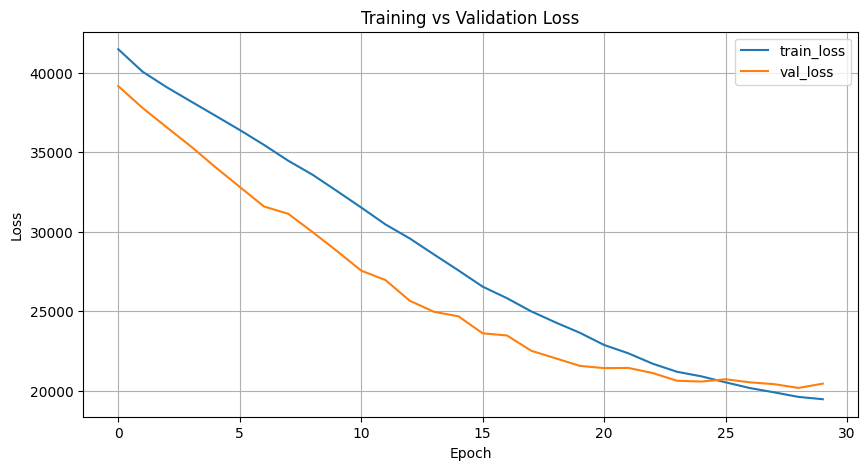

In [46]:

# ============================================
# Cell 46: Plot Total Loss
# ============================================

plt.figure(figsize=(10, 5))
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

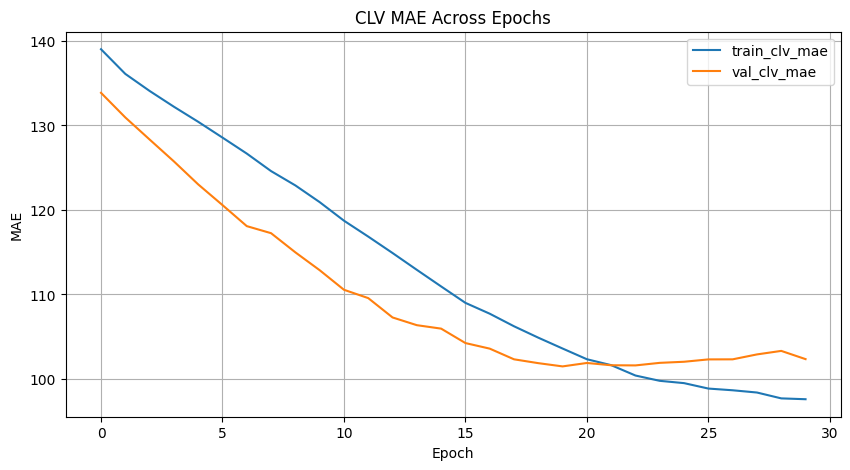

In [47]:

# ============================================
# Cell 47: Plot CLV MAE
# ============================================

plt.figure(figsize=(10, 5))
plt.plot(history_df["clv_output_mae"], label="train_clv_mae")
plt.plot(history_df["val_clv_output_mae"], label="val_clv_mae")
plt.title("CLV MAE Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()

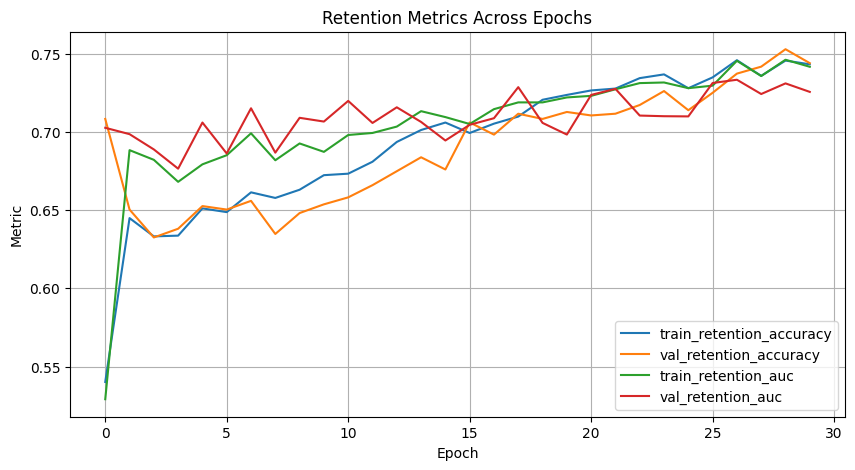

In [48]:

# ============================================
# Cell 48: Plot Retention Metrics
# ============================================

plt.figure(figsize=(10, 5))
plt.plot(history_df["retention_output_accuracy"], label="train_retention_accuracy")
plt.plot(history_df["val_retention_output_accuracy"], label="val_retention_accuracy")
plt.plot(history_df["retention_output_auc"], label="train_retention_auc")
plt.plot(history_df["val_retention_output_auc"], label="val_retention_auc")
plt.title("Retention Metrics Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.legend()
plt.grid(True)
plt.show()

## 15. Prediction Phase

In [49]:

# ============================================
# Cell 49: Predict on Test Set
# ============================================

pred_reg_test, pred_cls_test = model.predict(test_inputs, verbose=0)

pred_reg_test = pred_reg_test.reshape(-1)
pred_cls_test = pred_cls_test.reshape(-1)
pred_cls_label = (pred_cls_test >= 0.50).astype(int)

print("Predictions generated successfully.")

Predictions generated successfully.


## 16. Evaluation Metrics

For this project:
- **BLEU is not applicable** because this is not a text generation problem.
- We use:
  - regression metrics for CLV,
  - classification metrics for retention.

In [50]:

# ============================================
# Cell 50: Regression Metrics
# ============================================

regression_results = {
    "MAE": mean_absolute_error(y_test_reg, pred_reg_test),
    "RMSE": np.sqrt(mean_squared_error(y_test_reg, pred_reg_test)),
    "R2": r2_score(y_test_reg, pred_reg_test),
    "MAPE": mean_absolute_percentage_error(y_test_reg + 1e-6, pred_reg_test + 1e-6)
}

pd.DataFrame({
    "metric": list(regression_results.keys()),
    "value": list(regression_results.values())
})

,metric,value
0,MAE,1.036844e+02
1,RMSE,1.440139e+02
2,R2,9.238160e-02
3,MAPE,1.577732e+07


In [51]:

# ============================================
# Cell 51: Classification Metrics
# ============================================

classification_results = {
    "Accuracy": accuracy_score(y_test_cls, pred_cls_label),
    "F1 Score": f1_score(y_test_cls, pred_cls_label),
    "ROC AUC": roc_auc_score(y_test_cls, pred_cls_test)
}

pd.DataFrame({
    "metric": list(classification_results.keys()),
    "value": list(classification_results.values())
})

,metric,value
0,Accuracy,0.764182
1,F1 Score,0.843427
2,ROC AUC,0.730820


In [52]:

# ============================================
# Cell 52: Classification Report
# ============================================

print(classification_report(y_test_cls, pred_cls_label, digits=4))

              precision    recall  f1-score   support

         0.0     0.5273    0.5179    0.5225       224
         1.0     0.8409    0.8459    0.8434       675

    accuracy                         0.7642       899
   macro avg     0.6841    0.6819    0.6830       899
weighted avg     0.7628    0.7642    0.7635       899



In [53]:

# ============================================
# Cell 53: Confusion Matrix
# ============================================

cm = confusion_matrix(y_test_cls, pred_cls_label)
cm_df = pd.DataFrame(
    cm,
    index=["Actual_0", "Actual_1"],
    columns=["Pred_0", "Pred_1"]
)

cm_df

,Pred_0,Pred_1
Actual_0,116,108
Actual_1,104,571


## 17. Sample Outputs

In [54]:

# ============================================
# Cell 54: Build Prediction Table
# ============================================

prediction_table = test_df[["customer_id"]].copy()
prediction_table["actual_future_90d_revenue"] = y_test_reg
prediction_table["predicted_future_90d_revenue"] = pred_reg_test
prediction_table["actual_retained_90d"] = y_test_cls.astype(int)
prediction_table["predicted_retention_probability"] = pred_cls_test
prediction_table["predicted_retained_90d"] = pred_cls_label

prediction_table.head(10)

,customer_id,actual_future_90d_revenue,predicted_future_90d_revenue,actual_retained_90d,predicted_retention_probability,predicted_retained_90d
0,CUST_00368,479.390015,197.319702,1,0.918794,1
1,CUST_00259,146.190002,154.842926,1,0.865822,1
2,CUST_03789,371.470001,192.163391,1,0.912232,1
3,CUST_05274,0.000000,62.933510,0,0.739205,1
4,CUST_04038,0.000000,217.647430,0,0.936623,1
5,CUST_03423,197.929993,39.277092,1,0.710487,1
6,CUST_04277,252.800003,148.322906,1,0.858462,1
7,CUST_04208,404.529999,223.714783,1,0.941704,1
8,CUST_05776,101.040001,101.839058,1,0.767793,1
9,CUST_05163,0.000000,112.611015,0,0.796299,1


In [55]:

# ============================================
# Cell 55: Top Predicted High-Value Customers
# ============================================

prediction_table.sort_values("predicted_future_90d_revenue", ascending=False).head(10)

,customer_id,actual_future_90d_revenue,predicted_future_90d_revenue,actual_retained_90d,predicted_retention_probability,predicted_retained_90d
697,CUST_02505,15.960000,261.172211,1,0.962607,1
178,CUST_03578,519.700012,254.192337,1,0.959301,1
635,CUST_03113,91.139999,244.406891,1,0.953875,1
407,CUST_03778,323.779999,242.564072,1,0.952891,1
859,CUST_05747,73.900002,241.368469,1,0.952396,1
540,CUST_01591,450.660004,240.803787,1,0.951665,1
443,CUST_00160,420.959991,240.705429,1,0.952215,1
28,CUST_04733,124.839996,239.122467,1,0.951240,1
689,CUST_02837,0.000000,238.588730,0,0.950457,1
579,CUST_02668,353.380005,238.519424,1,0.951048,1


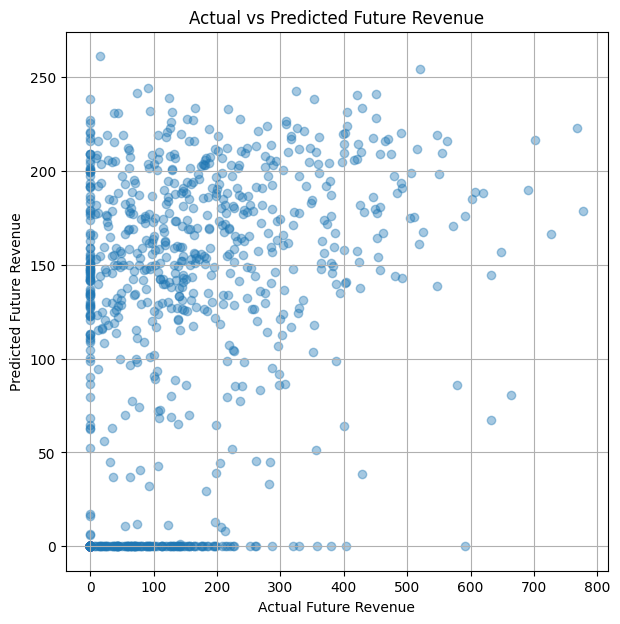

In [56]:

# ============================================
# Cell 56: Revenue Actual vs Predicted Plot
# ============================================

plt.figure(figsize=(7, 7))
plt.scatter(
    prediction_table["actual_future_90d_revenue"],
    prediction_table["predicted_future_90d_revenue"],
    alpha=0.4
)
plt.title("Actual vs Predicted Future Revenue")
plt.xlabel("Actual Future Revenue")
plt.ylabel("Predicted Future Revenue")
plt.grid(True)
plt.show()

## 18. Error Analysis

Strong portfolio projects should not stop at metrics.  
They should also show **where the model performs poorly**.

In [57]:

# ============================================
# Cell 57: Regression Error Analysis
# ============================================

prediction_table["abs_revenue_error"] = np.abs(
    prediction_table["actual_future_90d_revenue"] -
    prediction_table["predicted_future_90d_revenue"]
)

prediction_table["signed_revenue_error"] = (
    prediction_table["predicted_future_90d_revenue"] -
    prediction_table["actual_future_90d_revenue"]
)

prediction_table.sort_values("abs_revenue_error", ascending=False).head(10)

,customer_id,actual_future_90d_revenue,predicted_future_90d_revenue,actual_retained_90d,predicted_retention_probability,predicted_retained_90d,abs_revenue_error,signed_revenue_error
44,CUST_02416,778.020020,178.649261,1,0.898194,1,599.370728,-599.370728
611,CUST_01890,590.380005,0.000000,1,0.575852,1,590.380005,-590.380005
679,CUST_05401,663.140015,80.601868,1,0.748192,1,582.538147,-582.538147
698,CUST_05427,632.390015,67.164543,1,0.759984,1,565.225464,-565.225464
354,CUST_01775,726.039978,166.209442,1,0.883098,1,559.830566,-559.830566
45,CUST_00575,767.669983,222.867493,1,0.940269,1,544.802490,-544.802490
529,CUST_05996,689.729980,189.736130,1,0.911141,1,499.993835,-499.993835
227,CUST_02391,577.780029,86.087990,1,0.754072,1,491.692047,-491.692047
287,CUST_01944,647.130005,156.869629,1,0.866350,1,490.260376,-490.260376
867,CUST_02996,632.510010,144.431610,1,0.849041,1,488.078400,-488.078400


In [58]:

# ============================================
# Cell 58: Classification Error Analysis
# ============================================

cls_error_df = prediction_table[
    prediction_table["actual_retained_90d"] != prediction_table["predicted_retained_90d"]
].copy()

cls_error_df.head(10)

,customer_id,actual_future_90d_revenue,predicted_future_90d_revenue,actual_retained_90d,predicted_retention_probability,predicted_retained_90d,abs_revenue_error,signed_revenue_error
3,CUST_05274,0.000000,62.933510,0,0.739205,1,62.933510,62.933510
4,CUST_04038,0.000000,217.647430,0,0.936623,1,217.647430,217.647430
9,CUST_05163,0.000000,112.611015,0,0.796299,1,112.611015,112.611015
15,CUST_05654,89.720001,0.000000,1,0.430197,0,89.720001,-89.720001
23,CUST_02588,81.400002,0.000000,1,0.481696,0,81.400002,-81.400002
35,CUST_01729,186.139999,0.000000,1,0.435698,0,186.139999,-186.139999
41,CUST_05474,0.000000,176.669724,0,0.895664,1,176.669724,176.669724
47,CUST_03581,0.000000,79.620110,0,0.775148,1,79.620110,79.620110
50,CUST_00086,0.000000,209.233643,0,0.929448,1,209.233643,209.233643
59,CUST_02966,0.000000,178.834579,0,0.899611,1,178.834579,178.834579


In [59]:

# ============================================
# Cell 59: Analyze Errors by Revenue Bucket
# ============================================

prediction_table["actual_revenue_bucket"] = pd.qcut(
    prediction_table["actual_future_90d_revenue"].rank(method="first"),
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

bucket_error_summary = prediction_table.groupby("actual_revenue_bucket").agg(
    avg_actual_revenue=("actual_future_90d_revenue", "mean"),
    avg_predicted_revenue=("predicted_future_90d_revenue", "mean"),
    avg_abs_error=("abs_revenue_error", "mean"),
    retention_accuracy=("actual_retained_90d", lambda s: np.nan)
).reset_index()

bucket_error_summary

,actual_revenue_bucket,avg_actual_revenue,avg_predicted_revenue,avg_abs_error,retention_accuracy
0,Very Low,0.000000,62.055077,62.055077,NaN
1,Low,28.350611,99.134460,88.746178,NaN
2,Medium,107.091896,114.341698,67.675941,NaN
3,High,194.355774,136.645798,70.133652,NaN
4,Very High,392.112885,162.501984,229.610901,NaN


In [60]:

# ============================================
# Cell 60: Better Error Summary with Group Metrics
# ============================================

bucket_metrics = []

for bucket, sub_df in prediction_table.groupby("actual_revenue_bucket"):
    bucket_metrics.append({
        "revenue_bucket": bucket,
        "count": len(sub_df),
        "avg_actual_revenue": sub_df["actual_future_90d_revenue"].mean(),
        "avg_predicted_revenue": sub_df["predicted_future_90d_revenue"].mean(),
        "avg_abs_error": sub_df["abs_revenue_error"].mean(),
        "retention_accuracy": accuracy_score(
            sub_df["actual_retained_90d"],
            sub_df["predicted_retained_90d"]
        )
    })

bucket_metrics_df = pd.DataFrame(bucket_metrics).sort_values("avg_actual_revenue")
bucket_metrics_df

,revenue_bucket,count,avg_actual_revenue,avg_predicted_revenue,avg_abs_error,retention_accuracy
0,Very Low,180,0.000000,62.055077,62.055077,0.527778
1,Low,180,28.350613,99.134476,88.746178,0.677778
2,Medium,179,107.091896,114.341713,67.675941,0.793296
3,High,180,194.355774,136.645813,70.133652,0.866667
4,Very High,180,392.112885,162.501999,229.610916,0.955556


## 19. Business Interpretation

Typical interpretations:
- high predicted CLV + high retention probability = priority upsell customers
- high CLV + low retention probability = save-risk premium customers
- low CLV + high retention probability = efficient steady customers
- low CLV + low retention probability = low-priority churn candidates

In [61]:

# ============================================
# Cell 61: Create Business Action Segments
# ============================================

prediction_table["business_action_group"] = np.select(
    [
        (prediction_table["predicted_future_90d_revenue"] >= prediction_table["predicted_future_90d_revenue"].quantile(0.75)) &
        (prediction_table["predicted_retention_probability"] >= 0.50),

        (prediction_table["predicted_future_90d_revenue"] >= prediction_table["predicted_future_90d_revenue"].quantile(0.75)) &
        (prediction_table["predicted_retention_probability"] < 0.50),

        (prediction_table["predicted_future_90d_revenue"] < prediction_table["predicted_future_90d_revenue"].quantile(0.75)) &
        (prediction_table["predicted_retention_probability"] >= 0.50)
    ],
    [
        "Upsell Priority",
        "Retention Save",
        "Stable Low-Mid Value"
    ],
    default="Low Priority"
)

prediction_table.head()

,customer_id,actual_future_90d_revenue,predicted_future_90d_revenue,actual_retained_90d,predicted_retention_probability,predicted_retained_90d,abs_revenue_error,signed_revenue_error,actual_revenue_bucket,business_action_group
0,CUST_00368,479.390015,197.319702,1,0.918794,1,282.070312,-282.070312,Very High,Upsell Priority
1,CUST_00259,146.190002,154.842926,1,0.865822,1,8.652924,8.652924,High,Stable Low-Mid Value
2,CUST_03789,371.470001,192.163391,1,0.912232,1,179.306610,-179.306610,Very High,Upsell Priority
3,CUST_05274,0.000000,62.933510,0,0.739205,1,62.933510,62.933510,Very Low,Stable Low-Mid Value
4,CUST_04038,0.000000,217.647430,0,0.936623,1,217.647430,217.647430,Very Low,Upsell Priority


In [62]:

# ============================================
# Cell 62: Business Action Summary
# ============================================

business_summary = prediction_table.groupby("business_action_group").agg(
    customers=("customer_id", "count"),
    avg_predicted_revenue=("predicted_future_90d_revenue", "mean"),
    avg_retention_probability=("predicted_retention_probability", "mean")
).sort_values("avg_predicted_revenue", ascending=False)

business_summary

,customers,avg_predicted_revenue,avg_retention_probability
business_action_group,,,
Upsell Priority,225,205.499969,0.925243
Stable Low-Mid Value,454,125.749771,0.819056
Low Priority,220,0.000000,0.437024


## 20. Save Model Artifacts

In [63]:

# ============================================
# Cell 63: Save Core Artifacts
# ============================================

model.save(ARTIFACTS_DIR / "clv_ann_model.keras")

pd.to_pickle(scaler, ARTIFACTS_DIR / "numeric_scaler.pkl")
pd.to_pickle(label_encoders, ARTIFACTS_DIR / "label_encoders.pkl")
prediction_table.to_csv(ARTIFACTS_DIR / "test_predictions.csv", index=False)
history_df.to_csv(ARTIFACTS_DIR / "training_history.csv", index=False)

print("Artifacts saved successfully.")

Artifacts saved successfully.


## 21. Optional Deployment Demo

Below is a small inference helper that can be wrapped inside:
- Streamlit,
- Gradio,
- FastAPI,
- Flask.

This makes the project more portfolio-ready.

In [64]:

# ============================================
# Cell 64: Single-Customer Inference Helper
# ============================================

def prepare_single_customer_payload(raw_dict, scaler, label_encoders):
    numeric_array = np.array([[raw_dict[col] for col in numeric_features]], dtype="float32")
    numeric_array = scaler.transform(numeric_array)

    payload = {"numeric_input": numeric_array}

    for col in categorical_features:
        value = str(raw_dict[col])

        if value not in set(label_encoders[col].classes_):
            value = label_encoders[col].classes_[0]

        encoded_value = label_encoders[col].transform([value])[0]
        payload[f"{col}_input"] = np.array([encoded_value])

    return payload

In [65]:

# ============================================
# Cell 65: Demo Prediction Function
# ============================================

def predict_single_customer(raw_dict):
    payload = prepare_single_customer_payload(raw_dict, scaler, label_encoders)
    pred_reg, pred_cls = model.predict(payload, verbose=0)

    return {
        "predicted_future_90d_revenue": float(pred_reg.reshape(-1)[0]),
        "predicted_retention_probability": float(pred_cls.reshape(-1)[0]),
        "predicted_retained_90d": int((pred_cls.reshape(-1)[0] >= 0.50))
    }

In [66]:

# ============================================
# Cell 66: Sample Deployment Input
# ============================================

sample_customer = {
    "n_orders": 12,
    "total_revenue": 950.0,
    "avg_order_value": 79.0,
    "std_order_value": 24.0,
    "total_quantity": 42,
    "avg_quantity": 3.5,
    "category_diversity": 4,
    "payment_diversity": 2,
    "channel_diversity": 3,
    "avg_discount": 0.08,
    "recency_days": 18,
    "tenure_days": 310,
    "orders_per_month": 1.15,
    "revenue_per_month": 92.0,
    "loyalty_score": 74.0,
    "discount_sensitivity": 0.22,
    "engagement_score": 81.0,
    "cohort_age_months": 10.0,
    "avg_revenue_per_active_month": 95.0,
    "country": "United Kingdom",
    "preferred_channel": "Web",
    "dominant_category": "Electronics",
    "acquisition_quarter": "2024Q1",
    "customer_segment_name": "Segment_0"
}

predict_single_customer(sample_customer)

{'predicted_future_90d_revenue': 28.820125579833984,
 'predicted_retention_probability': 0.7382904291152954,
 'predicted_retained_90d': 1}

## 22. Final Notes

### What makes this project strong
- real business framing,
- time-aware CLV forecasting,
- customer segmentation,
- embeddings for categorical features,
- multi-task ANN design,
- regression + retention outputs,
- error analysis,
- deployment-ready inference helper.

### Metrics note
Because this is **not** a text generation problem:
- **BLEU is not applicable**
- the correct evaluation metrics are:
  - **MAE / RMSE / R² / MAPE** for CLV regression
  - **Accuracy / F1 / ROC-AUC** for retention classification

This is the honest and correct ML framing for the project.